In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [13]:
df.describe()


,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


## Partie 1 – Graphique linéaire (Line Plot)

### 1) Évolution de la température en fonction du temps

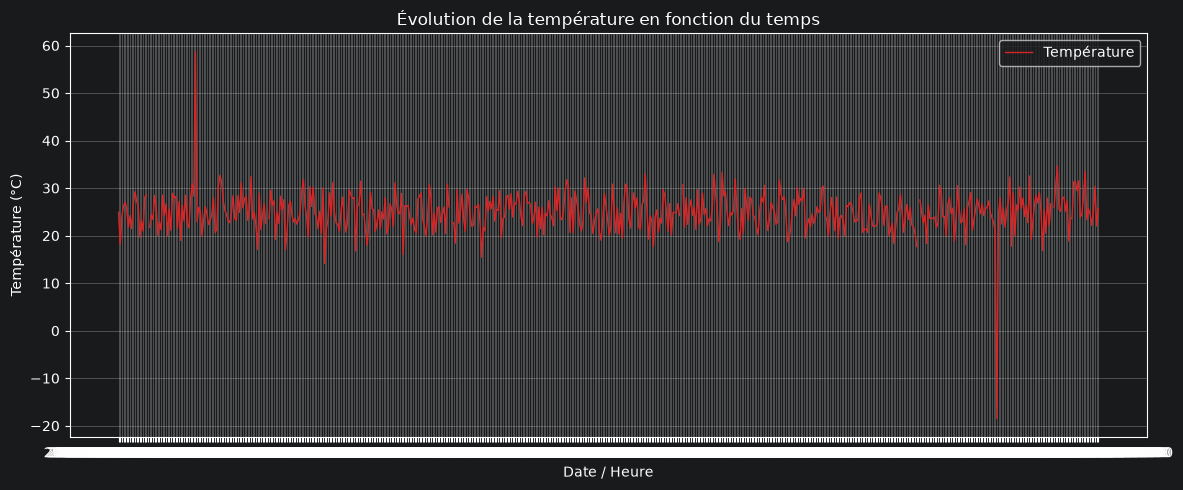

In [14]:
df_sorted = df.sort_values("date_heure")

plt.figure(figsize=(12, 5))
plt.plot(df_sorted["date_heure"], df_sorted["temperature"],
         color="tab:red", linewidth=1, label="Température")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 2) Valeurs anormales identifiées visuellement

En observant la courbe, deux points sortent nettement du nuage principal (qui oscille globalement
entre 15°C et 35°C) :

- une valeur **très négative (≈ -18,5 °C)** le 27/01/2026, sur le bâtiment B004,
- une valeur **très élevée (≈ 58,7 °C)** le 06/01/2026, sur le bâtiment B004.

Ces deux mesures sont physiquement incohérentes pour un environnement intérieur/extérieur normal :
ce sont très probablement des **erreurs de capteur** (dysfonctionnement, mauvaise calibration ou bruit
de transmission) plutôt que de vraies variations climatiques.

In [15]:
# Vérification chiffrée des valeurs extrêmes repérées visuellement
df[(df["temperature"] < 0) | (df["temperature"] > 45)][
    ["date_heure", "batiment", "id_capteur", "temperature"]
]


,date_heure,batiment,id_capteur,temperature
487,2026-01-27 09:00:00,B004,C010,-18.5
502,2026-01-06 23:00:00,B004,C012,58.7


## Partie 2 – Diagramme en barres (Bar Chart)

### 1) Consommation moyenne par bâtiment

In [16]:
consommation_batiment = df.groupby("batiment")["consommation"].mean().sort_index()
consommation_batiment


batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

### 2) Comparaison verticale

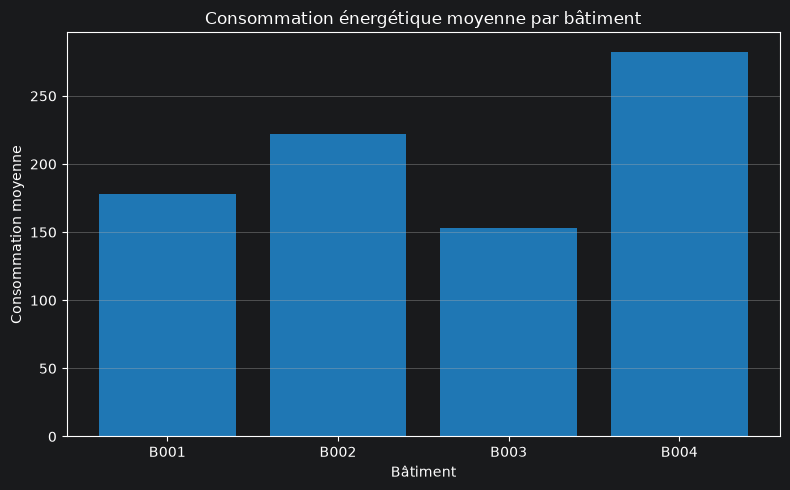

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values, color="tab:blue")
plt.title("Consommation énergétique moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### 3) Comparaison horizontale

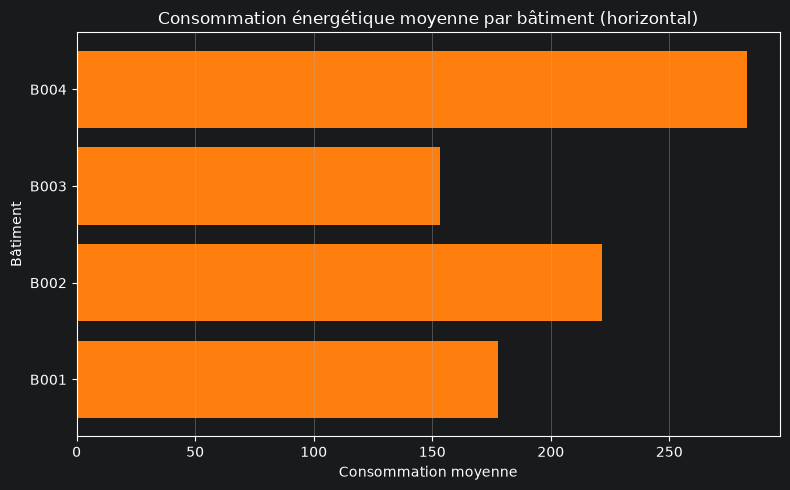

In [19]:
plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values, color="tab:orange")
plt.title("Consommation énergétique moyenne par bâtiment (horizontal)")
plt.xlabel("Consommation moyenne")
plt.ylabel("Bâtiment")
plt.grid(axis="x")
plt.tight_layout()
plt.show()


### 4) Quand un graphique horizontal est-il plus lisible ?

- Quand les **libellés des catégories sont longs** (noms de bâtiments, de villes, de projets…) : en
  horizontal, le texte reste lisible à plat au lieu d'être tourné ou tronqué en vertical.
- Quand il y a **beaucoup de catégories** à comparer : un barh permet d'empiler les barres verticalement
  sans les tasser horizontalement.
- Quand on veut **classer/trier facilement** les catégories du plus grand au plus petit (lecture de haut
  en bas très naturelle).

## Partie 3 – Histogramme

### 1) Distribution de la température (20 classes, grille horizontale uniquement)

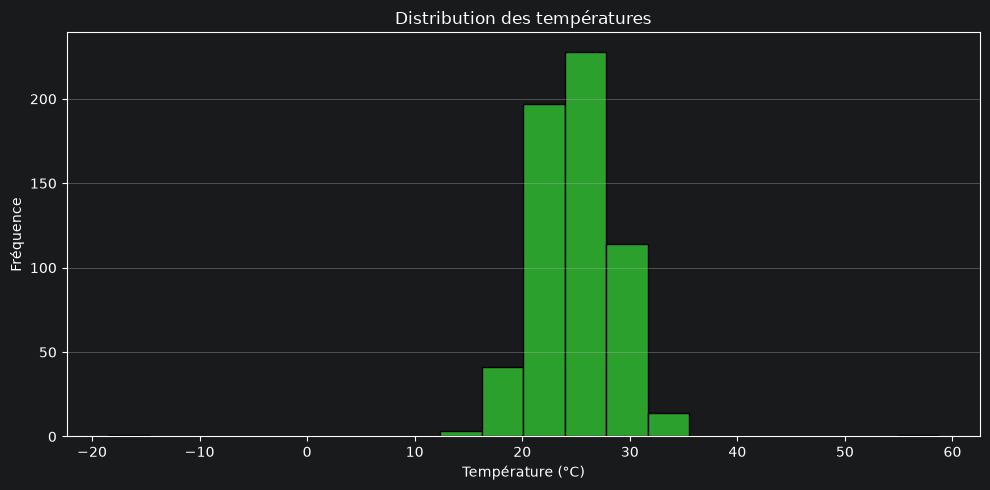

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(df["temperature"].dropna(), bins=20, color="tab:green", edgecolor="black")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### 2) Analyse de la distribution

- **Concentration :** la majorité des mesures se situent entre 20 °C et 30 °C environ, avec un pic
  autour de la médiane (≈ 24,9 °C).
- **Symétrie :** la distribution paraît globalement **symétrique et proche d'une loi normale**, centrée
  autour de sa moyenne.
- **Valeurs éloignées :** deux barres isolées apparaissent très loin du corps principal, correspondant
  aux deux valeurs extrêmes repérées en Partie 1 (≈ -18,5 °C et ≈ 58,7 °C).
- **Valeurs aberrantes :** oui, ces deux points sont clairement des **outliers** — ils s'écartent de
  plus de 8 écarts-types de la moyenne, ce qui confirme une anomalie de mesure plutôt qu'une variation
  naturelle.

### 3) Distribution de la consommation — 20 classes

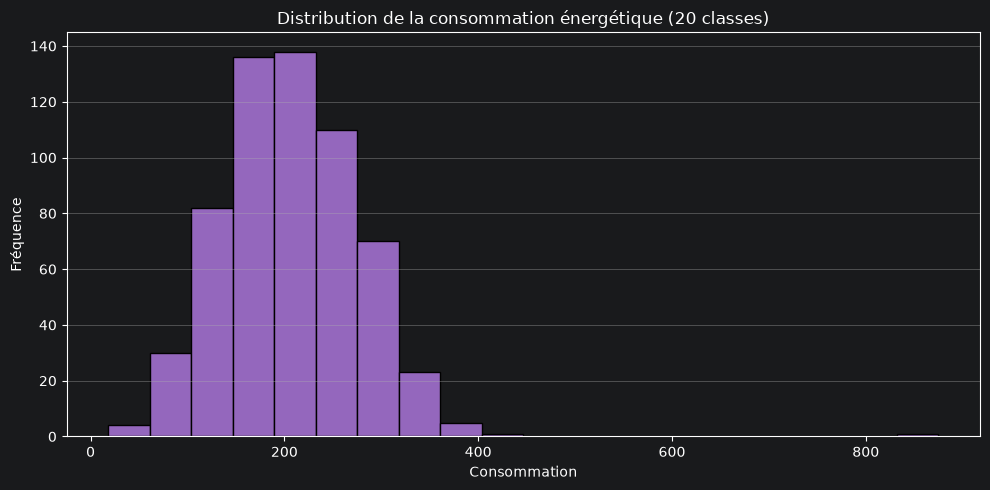

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(df["consommation"].dropna(), bins=20, color="tab:purple", edgecolor="black")
plt.title("Distribution de la consommation énergétique (20 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


#### a) Avec 10 classes

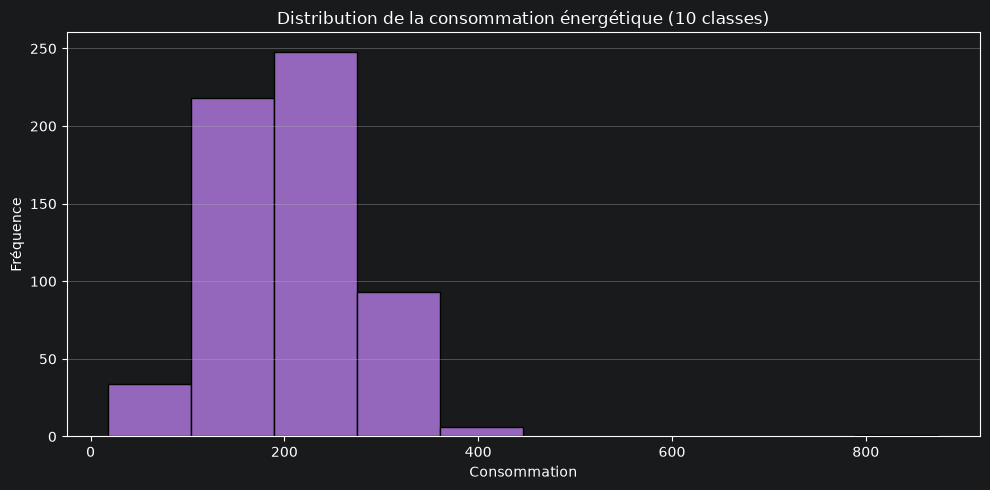

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(df["consommation"].dropna(), bins=10, color="tab:purple", edgecolor="black")
plt.title("Distribution de la consommation énergétique (10 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


#### b) Avec 30 classes

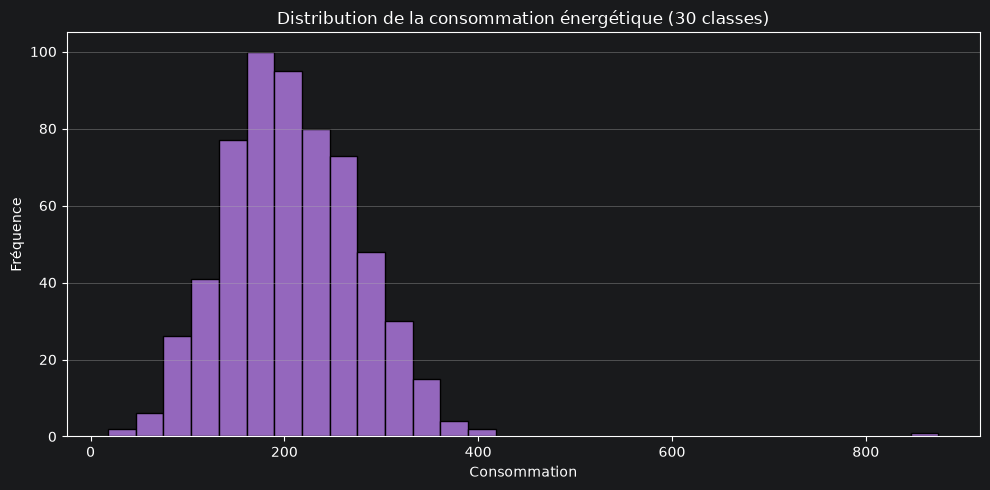

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(df["consommation"].dropna(), bins=30, color="tab:purple", edgecolor="black")
plt.title("Distribution de la consommation énergétique (30 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


#### c) Impact du nombre de classes sur l'interprétation

- **Peu de classes (10) :** l'histogramme est plus lisse, il montre la **tendance générale** de la
  distribution mais masque les détails fins et peut cacher de petites irrégularités ou des outliers.
- **Beaucoup de classes (30) :** l'histogramme devient plus **détaillé et « bruité »** : on distingue
  mieux les valeurs isolées (comme le pic à 875), mais la forme globale est plus difficile à percevoir
  d'un coup d'œil, et certaines barres deviennent quasi vides.
- Un nombre de classes trop faible **sur-simplifie** les données, un nombre trop élevé **sur-segmente**
  et peut faire perdre la vision d'ensemble. Le choix (ici 20) est un compromis raisonnable entre les
  deux.